# AI Basic Tasks — YoungDev Interns
### 01 Month Remote Internship
---
| Task | Topic |
|------|-------|
| 1 | Simple Linear Regression |
| 2 | Exploratory Data Analysis with Basic Statistics |
| 3 | Basic Classification Model |


---
## Task 1 — Simple Linear Regression
Train a linear regression model on a single-feature dataset, evaluate with MSE and R², and visualise the fit.


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ── Dataset ───────────────────────────────────────────────────────────────────
np.random.seed(42)
X = 2 * np.random.rand(150, 1)
y = 3 + 5 * X.ravel() + np.random.randn(150)

print(f"Samples : {len(X)}")
print(f"X range : [{X.min():.2f}, {X.max():.2f}]")
print(f"y range : [{y.min():.2f}, {y.max():.2f}]")


Samples : 150
X range : [0.01, 1.97]
y range : [0.27, 14.89]


In [2]:
# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ── Train Model ───────────────────────────────────────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Intercept (β₀) : {model.intercept_:.4f}  (true ≈ 3.0)")
print(f"Slope     (β₁) : {model.coef_[0]:.4f}  (true ≈ 5.0)")


Intercept (β₀) : 2.9650  (true ≈ 3.0)
Slope     (β₁) : 5.1432  (true ≈ 5.0)


In [3]:
# ── Evaluate ──────────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


MSE  : 0.4748
RMSE : 0.6891
R²   : 0.9502


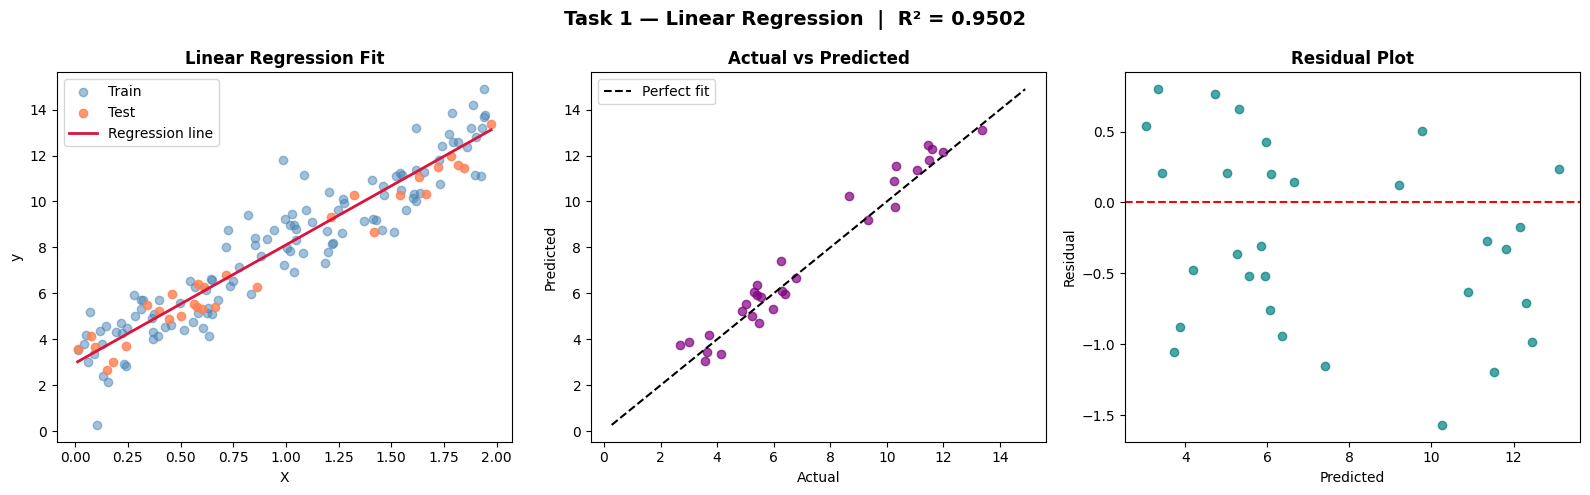

Task 1 complete!


In [4]:
# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Regression fit
x_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
axes[0].scatter(X_train, y_train, color='steelblue', alpha=0.5, label='Train')
axes[0].scatter(X_test,  y_test,  color='coral',     alpha=0.8, label='Test')
axes[0].plot(x_line, model.predict(x_line), color='crimson', lw=2, label='Regression line')
axes[0].set_title('Linear Regression Fit', fontweight='bold')
axes[0].set_xlabel('X'); axes[0].set_ylabel('y'); axes[0].legend()

# 2. Actual vs Predicted
axes[1].scatter(y_test, y_pred, color='purple', alpha=0.7)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=1.5, label='Perfect fit')
axes[1].set_title('Actual vs Predicted', fontweight='bold')
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted'); axes[1].legend()

# 3. Residuals
residuals = y_test - y_pred
axes[2].scatter(y_pred, residuals, color='teal', alpha=0.7)
axes[2].axhline(0, color='red', linestyle='--', lw=1.5)
axes[2].set_title('Residual Plot', fontweight='bold')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Residual')

plt.suptitle(f'Task 1 — Linear Regression  |  R² = {r2:.4f}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Task 1 complete!")


---
## Task 2 — Exploratory Data Analysis with Basic Statistics
Load the Iris dataset, compute descriptive statistics, and visualise distributions.


In [5]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# ── Load Data ─────────────────────────────────────────────────────────────────
iris_bunch = load_iris(as_frame=True)
df = iris_bunch.frame.copy()
df['species'] = df['target'].map(dict(enumerate(iris_bunch.target_names)))
df.drop(columns='target', inplace=True)

print("Shape:", df.shape)
print("\nClass distribution:")
print(df['species'].value_counts())
print("\nFirst 5 rows:")
df.head()


Shape: (150, 5)

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
# ── Descriptive Statistics ────────────────────────────────────────────────────
features = ['sepal length (cm)', 'sepal width (cm)',
            'petal length (cm)', 'petal width (cm)']

stats = df[features].agg(['mean', 'median', 'std', 'min', 'max']).T
stats.columns = ['Mean', 'Median', 'Std Dev', 'Min', 'Max']
stats = stats.round(3)

print("=== Descriptive Statistics ===")
print(stats.to_string())


=== Descriptive Statistics ===
                    Mean  Median  Std Dev  Min  Max
sepal length (cm)  5.843    5.80    0.828  4.3  7.9
sepal width (cm)   3.057    3.00    0.436  2.0  4.4
petal length (cm)  3.758    4.35    1.765  1.0  6.9
petal width (cm)   1.199    1.30    0.762  0.1  2.5


In [7]:
# ── Check Missing Values ──────────────────────────────────────────────────────
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")


Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Total missing: 0


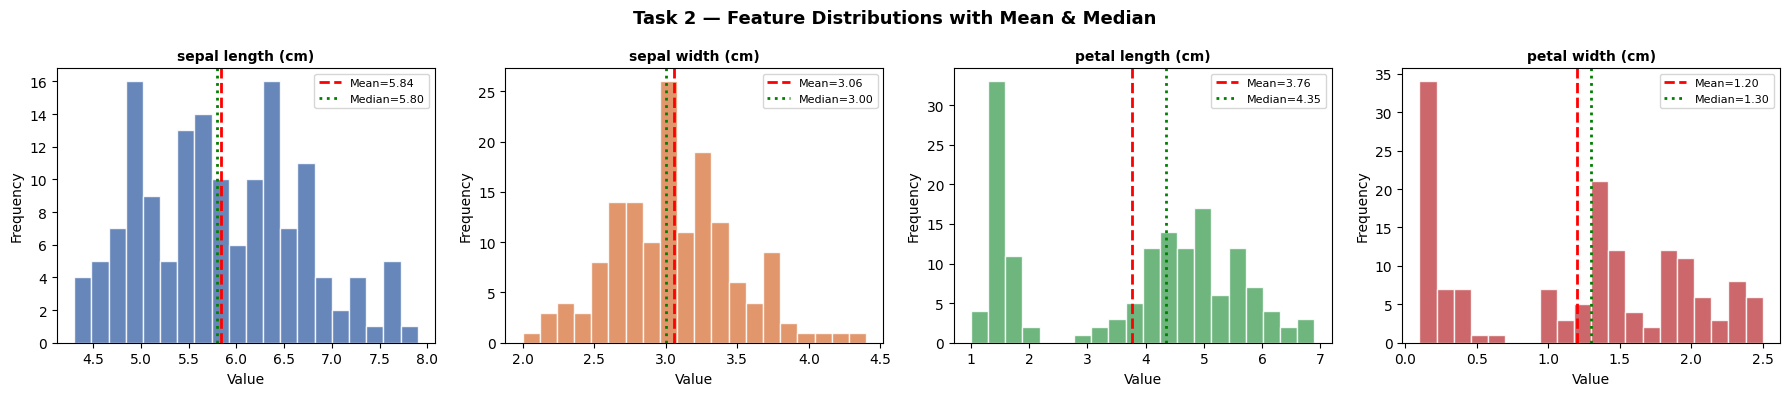

In [8]:
# ── Histograms with Mean & Median ─────────────────────────────────────────────
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, feat, col in zip(axes, features, colors):
    ax.hist(df[feat], bins=20, color=col, edgecolor='white', alpha=0.85)
    ax.axvline(df[feat].mean(),   color='red',   linestyle='--', lw=2, label=f"Mean={df[feat].mean():.2f}")
    ax.axvline(df[feat].median(), color='green', linestyle=':',  lw=2, label=f"Median={df[feat].median():.2f}")
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle('Task 2 — Feature Distributions with Mean & Median', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_13204\2750839370.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feat, palette=palette, ax=ax)
C:\Users\Admin\AppData\Local\Temp\ipykernel_13204\2750839370.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feat, palette=palette, ax=ax)
C:\Users\Admin\AppData\Local\Temp\ipykernel_13204\2750839370.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feat, palette=palette, ax=ax)
C:\Users\Admin\AppData\Local\Temp\ipykernel_13

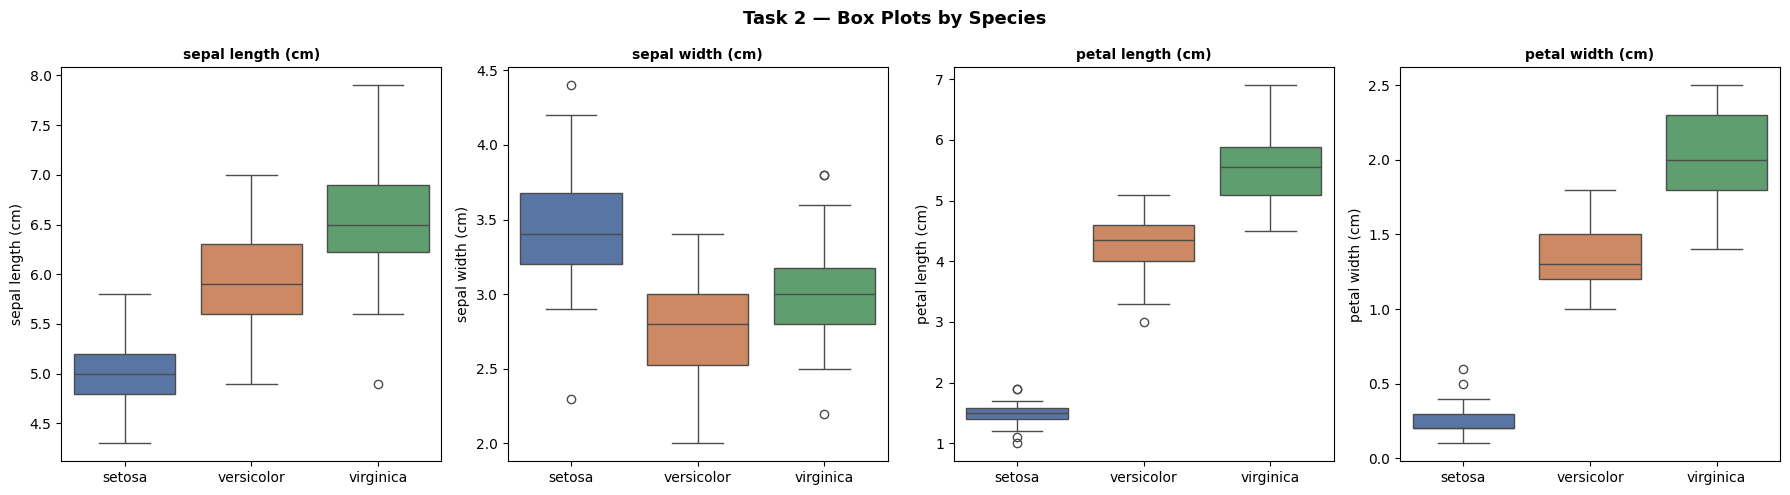

In [9]:
# ── Box Plots by Species ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
palette = {'setosa': '#4C72B0', 'versicolor': '#DD8452', 'virginica': '#55A868'}

for ax, feat in zip(axes, features):
    sns.boxplot(data=df, x='species', y=feat, palette=palette, ax=ax)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Task 2 — Box Plots by Species', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


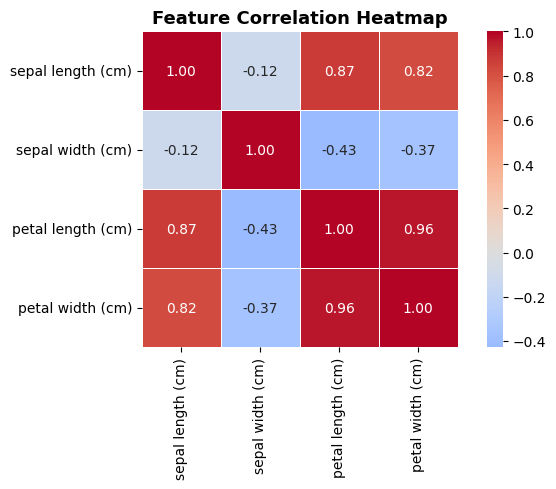

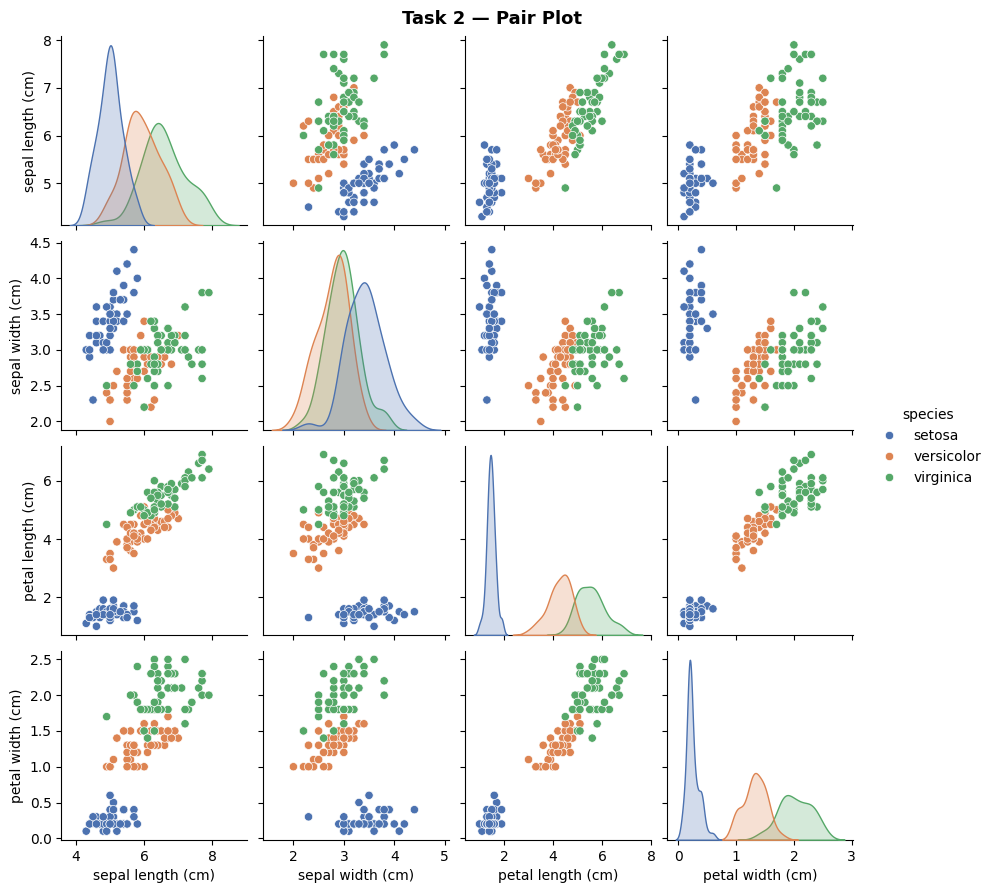

Task 2 complete!


In [10]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Pair Plot ─────────────────────────────────────────────────────────────────
sns.pairplot(df, hue='species', palette=palette, diag_kind='kde', height=2.2)
plt.suptitle('Task 2 — Pair Plot', y=1.01, fontsize=13, fontweight='bold')
plt.show()
print("Task 2 complete!")


---
## Task 3 — Basic Classification Model
Train Logistic Regression and Decision Tree classifiers on the Iris dataset and compare performance.


In [11]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

# ── Load & Prepare Data ───────────────────────────────────────────────────────
iris_bunch = load_iris(as_frame=True)
X_cls = iris_bunch.data.values
y_cls = iris_bunch.target.values
target_names = iris_bunch.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
X_te_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Classes: {target_names}")


Train: (120, 4)  |  Test: (30, 4)
Classes: ['setosa' 'versicolor' 'virginica']


In [12]:
# ── Train Logistic Regression ─────────────────────────────────────────────────
lr = LogisticRegression(max_iter=300, random_state=42)
lr.fit(X_tr_sc, y_train)
y_pred_lr = lr.predict(X_te_sc)

print("=== Logistic Regression ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=target_names))


=== Logistic Regression ===
Accuracy : 0.9333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [13]:
# ── Train Decision Tree ───────────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("=== Decision Tree ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=target_names))


=== Decision Tree ===
Accuracy : 0.9333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



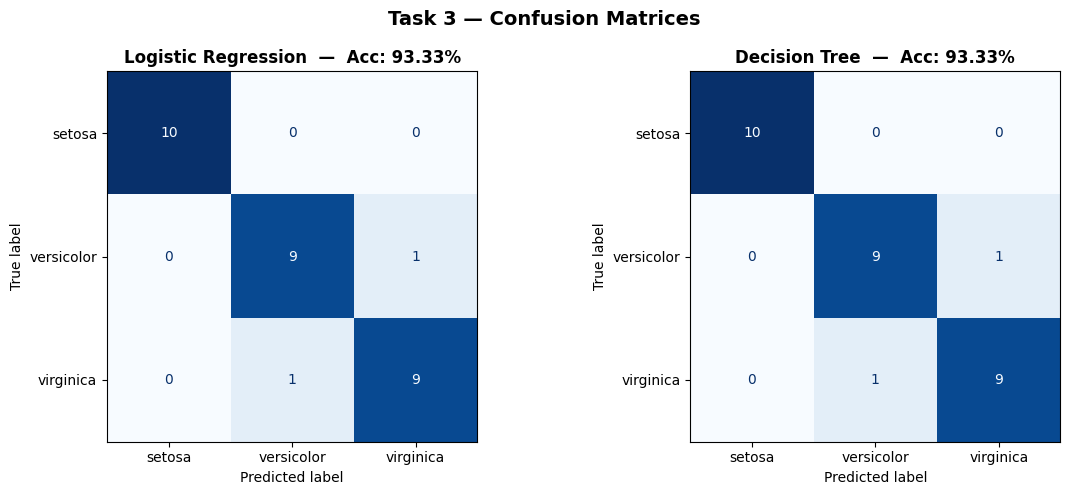

In [14]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, title in zip(axes,
                               [y_pred_lr, y_pred_dt],
                               ['Logistic Regression', 'Decision Tree']):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=target_names).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}  —  Acc: {accuracy_score(y_test, y_pred):.2%}',
                 fontsize=12, fontweight='bold')

plt.suptitle('Task 3 — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


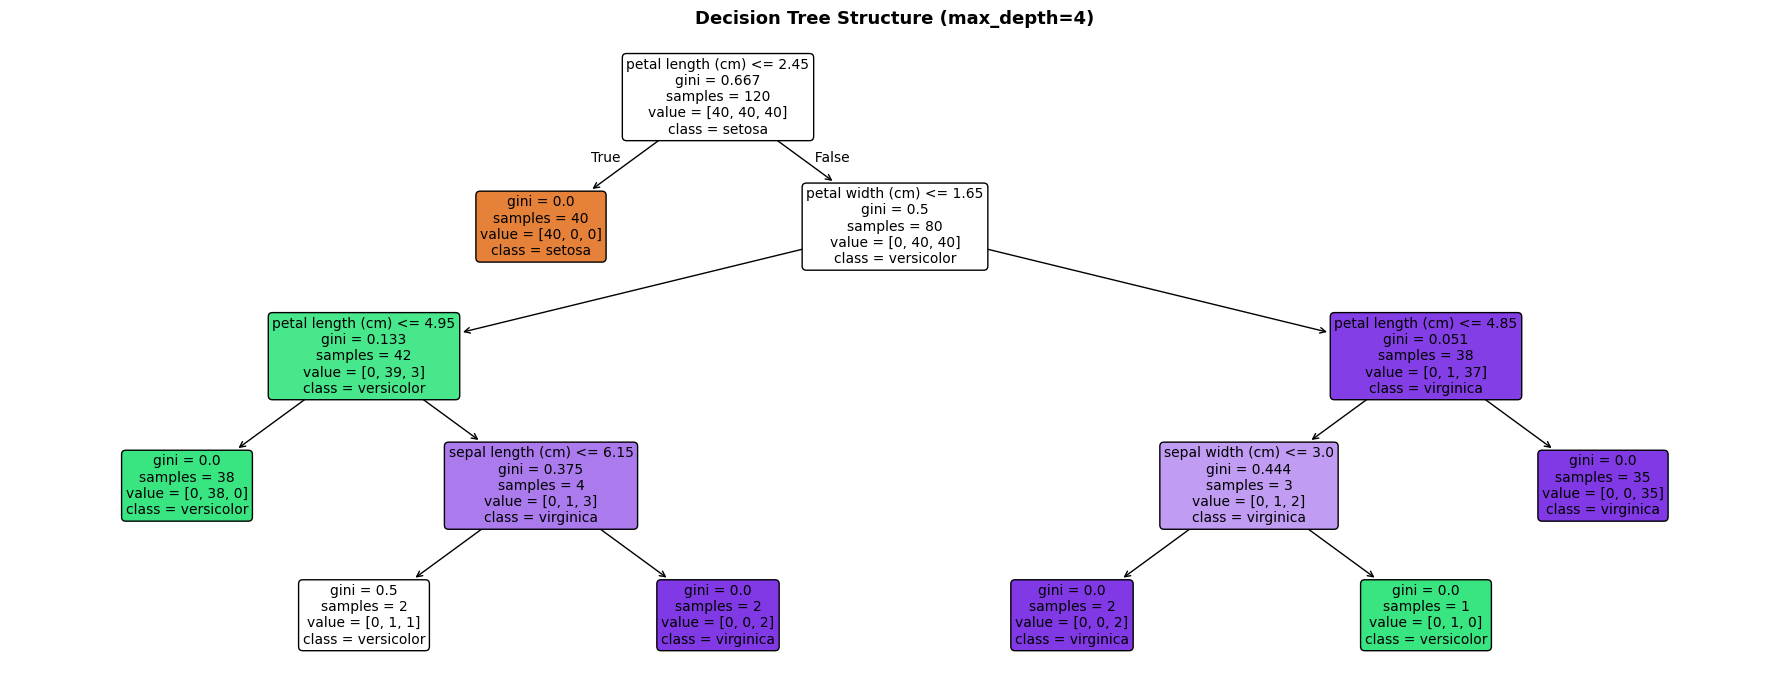

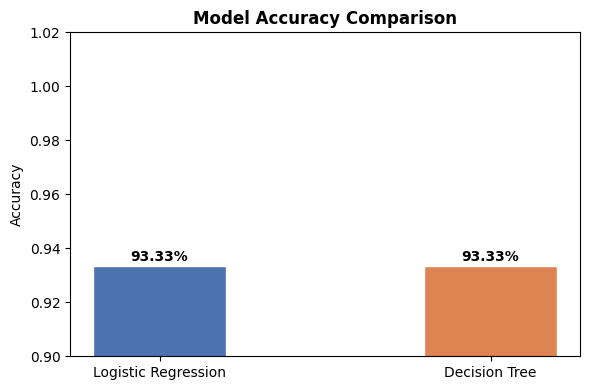

Task 3 complete!


In [15]:
# ── Decision Tree Visualisation ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(dt,
          feature_names=iris_bunch.feature_names,
          class_names=target_names,
          filled=True, rounded=True, fontsize=10, ax=ax)
ax.set_title('Decision Tree Structure (max_depth=4)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Accuracy Comparison ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
models  = ['Logistic Regression', 'Decision Tree']
scores  = [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_dt)]
bars = ax.bar(models, scores, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.4)
ax.set_ylim(0.9, 1.02)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison', fontweight='bold')
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, score + 0.002,
            f'{score:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print("Task 3 complete!")
